In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("diabetes.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'diabetes.csv'

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3854)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df["diabetes"].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

In [12]:
df["gender"].value_counts()


gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

In [13]:
df["smoking_history"].value_counts()

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

In [14]:
df = df[df['gender'] != 'Other']

In [17]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

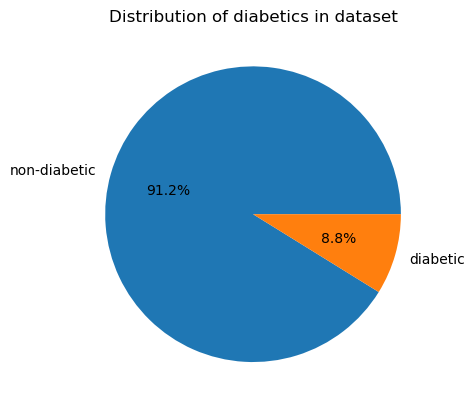

In [23]:
plt.pie(df['diabetes'].value_counts(), labels=['non-diabetic', 'diabetic'], autopct='%1.1f%%')
plt.title("Distribution of diabetics in dataset")
plt.show()

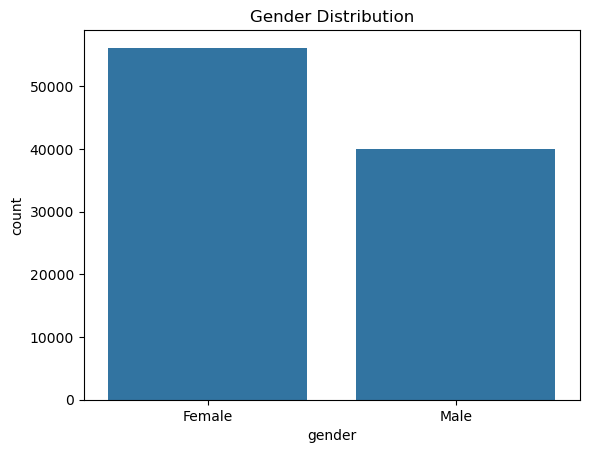

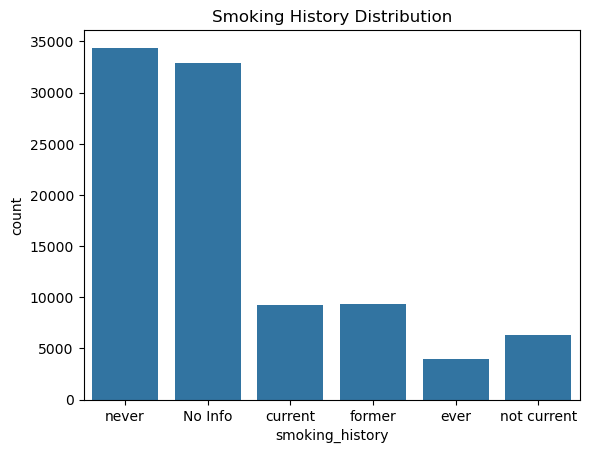

In [24]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

sns.countplot(x="smoking_history", data=df)
plt.title("Smoking History Distribution")
plt.show()

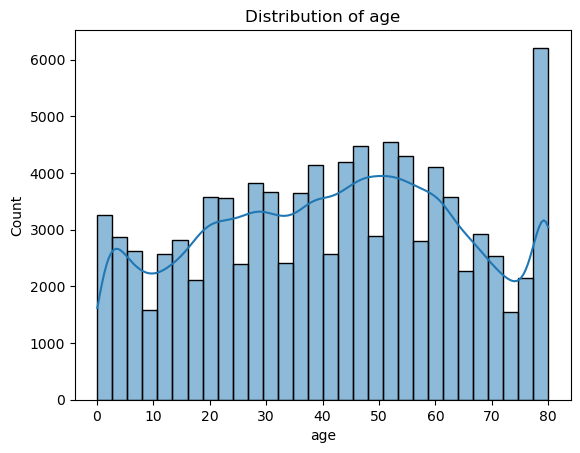

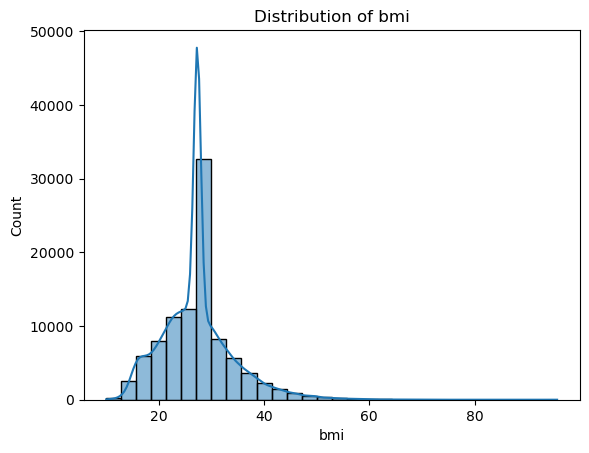

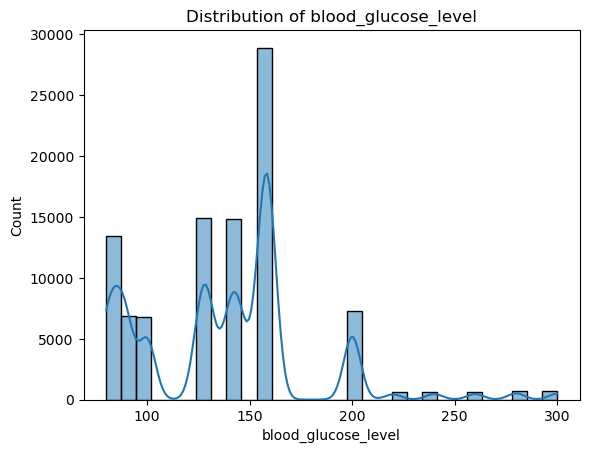

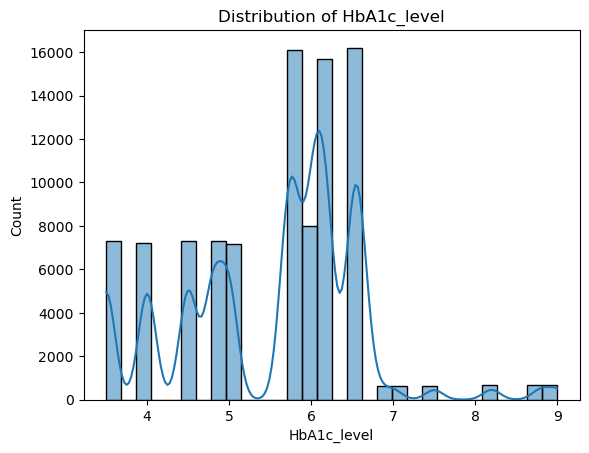

In [20]:
numeric_cols = ['age','bmi','blood_glucose_level','HbA1c_level']
for col in numeric_cols:
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

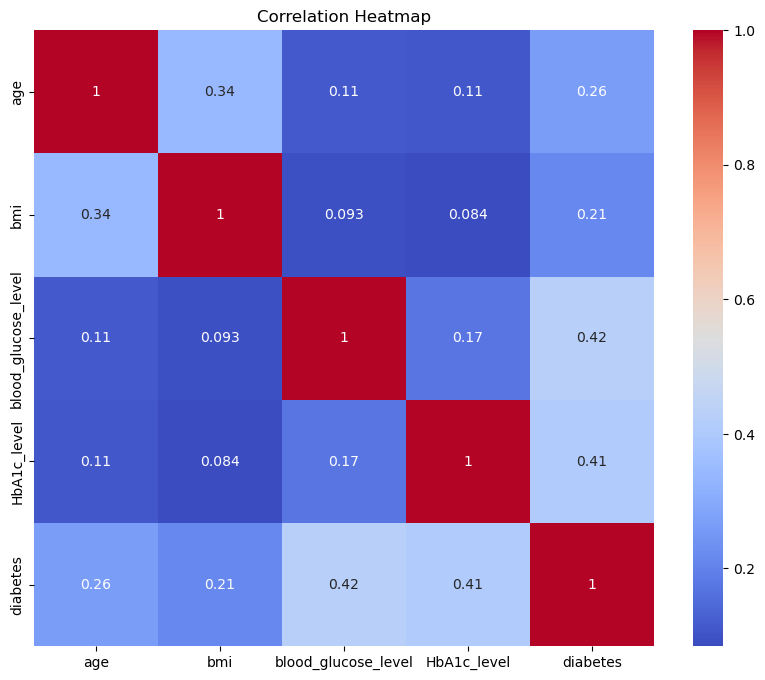

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols + ['diabetes']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

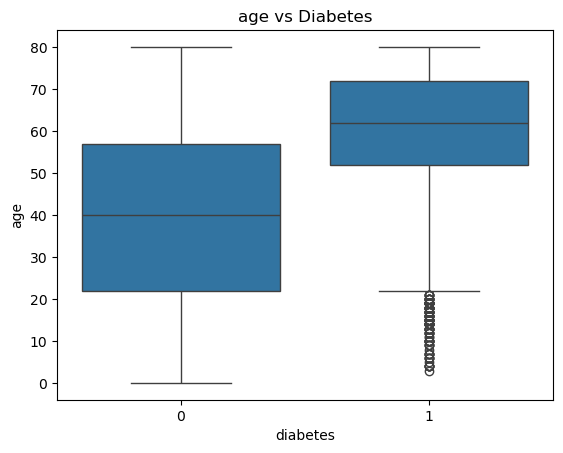

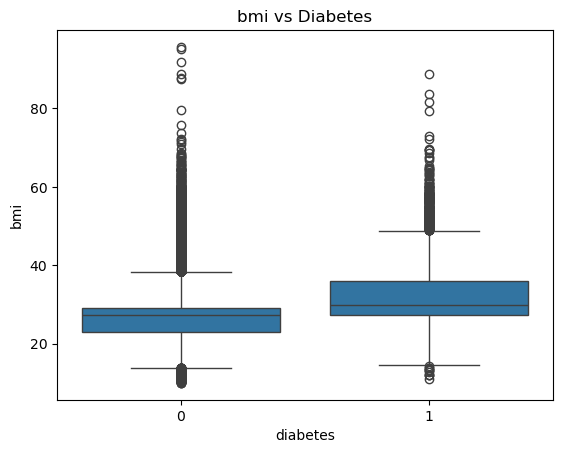

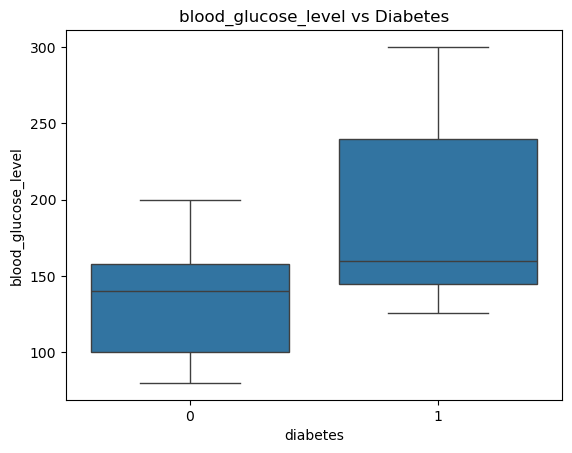

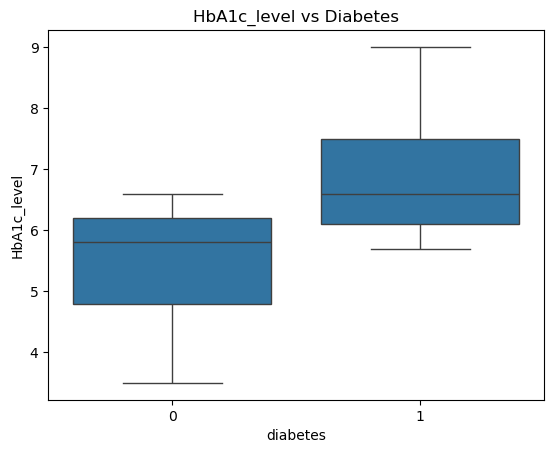

In [22]:
for col in numeric_cols:
    sns.boxplot(x="diabetes", y=col, data=df)
    plt.title(f"{col} vs Diabetes")
    plt.show()

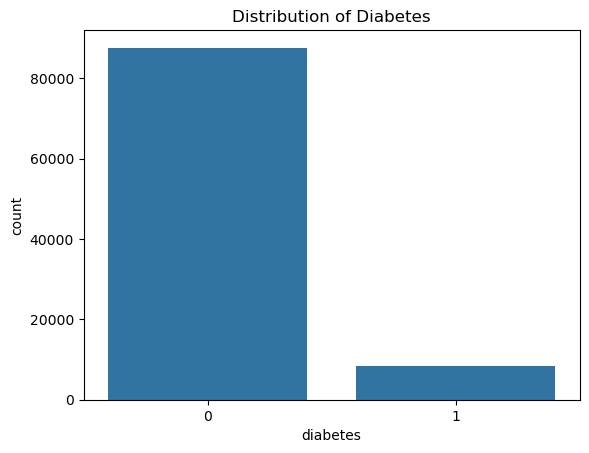

In [25]:
sns.countplot(x="diabetes", data=df)
plt.title("Distribution of Diabetes")
plt.show()

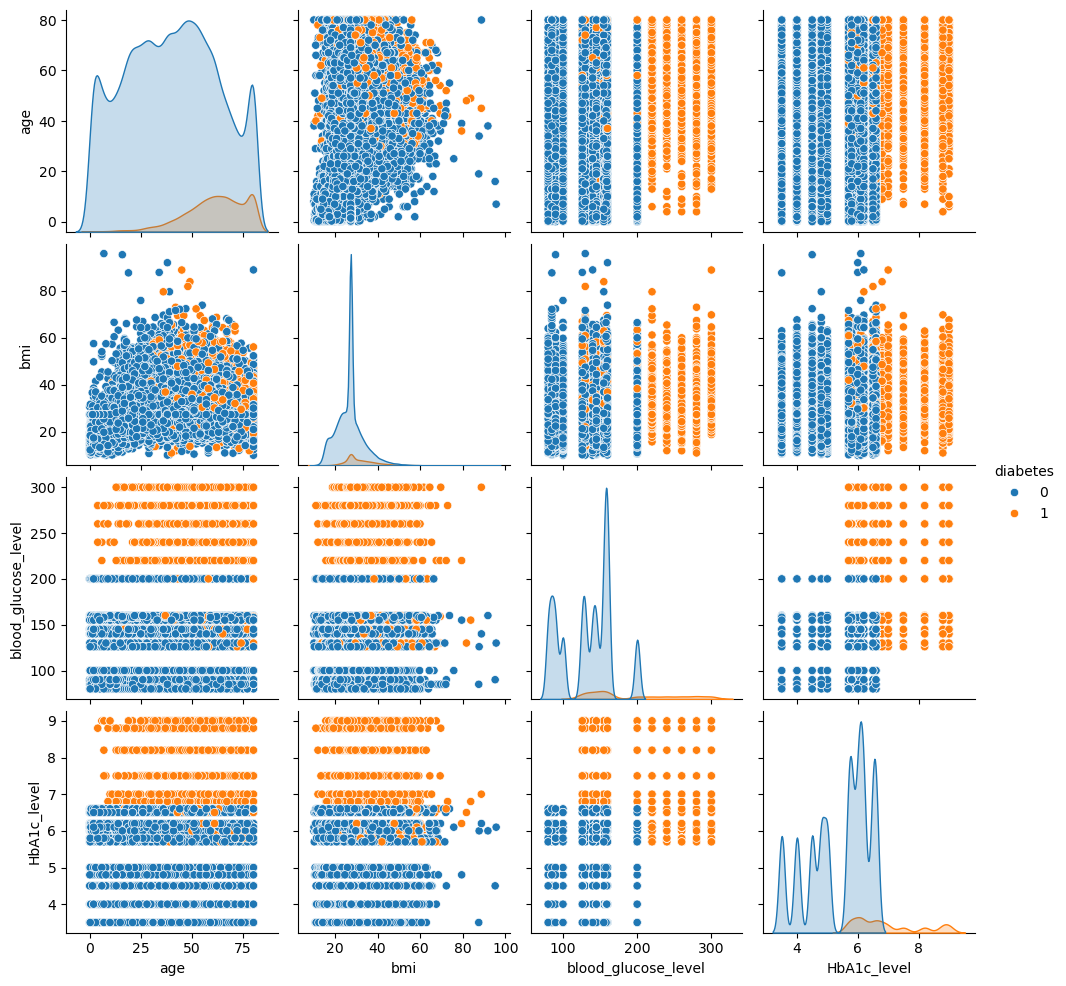

In [26]:
sns.pairplot(df[numeric_cols + ['diabetes']], hue='diabetes')
plt.show()

In [27]:
df = pd.get_dummies(df, columns=['gender','smoking_history'], drop_first=True)

In [28]:
df.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Male',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')

In [29]:
from sklearn.model_selection import train_test_split
X = df.drop("diabetes", axis=1)
y = df["diabetes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [47]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: diabetes
0    70121
1     6781
Name: count, dtype: int64
After SMOTE: diabetes
0    70121
1    70121
Name: count, dtype: int64


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=100)

model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Classification Report:\n", report)

Model Accuracy: 0.8915531051700821
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94     17525
           1       0.44      0.78      0.56      1701

    accuracy                           0.89     19226
   macro avg       0.71      0.84      0.75     19226
weighted avg       0.93      0.89      0.90     19226



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Classification Report:\n", report)

Model Accuracy: 0.9274420056173931
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     17525
           1       0.56      0.82      0.67      1701

    accuracy                           0.93     19226
   macro avg       0.77      0.88      0.81     19226
weighted avg       0.94      0.93      0.93     19226



In [54]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report


gb_model = GradientBoostingClassifier(
    n_estimators=200, 
    max_depth=5,       
    learning_rate=0.1,  
    random_state=42
)


gb_model.fit(X_train_res, y_train_res)


y_pred_gb = gb_model.predict(X_test)


accuracy_gb = accuracy_score(y_test, y_pred_gb)
report_gb = classification_report(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)
print("Classification Report:\n", report_gb)

Gradient Boosting Accuracy: 0.9671278477062312
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     17525
           1       0.92      0.69      0.79      1701

    accuracy                           0.97     19226
   macro avg       0.94      0.84      0.88     19226
weighted avg       0.97      0.97      0.96     19226

